In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_parquet('test_val_dataset.parquet')

In [3]:
df['fpts']

0       [271420.157, 2283167.321, 3388828.955, 2325726...
1       [818579.285, 259896.993, 80588.686, 744977.559...
2       [815.853, 2086.731, 36657.054, 6089.618, 38127...
3       [19245.721, 14237.357, 659.658, 2740.838, 4808...
4       [545424.953, 62564.482, 76724.397, 2171143.501...
                              ...                        
2649    [103088.405, 269569.261, 46247.804, 166835.55,...
2650    [8260.441, 208427.666, 197468.818, 12986.805, ...
2651    [33716.882, 38603.543, 13849.757, 452760.597, ...
2652    [4063.682, 728017.065, 872172.172, 5912.571, 3...
2653    [77258.143, 7532.243, 10179.547, 847.357, 1429...
Name: fpts, Length: 2654, dtype: object

In [4]:
mask_rows = df['fpts'].apply(lambda arr: not np.any(np.isnan(arr)))
df_subset = df[mask_rows]

In [5]:
for row in df_subset.itertuples():
    print(row.Index)
    if row.Index==0:
        print(row.fpts)

0
[2.71420157e+05 2.28316732e+06 3.38882896e+06 2.32572684e+06
 4.91434000e+02 3.15759146e+05 1.07672008e+06 9.96711400e+03
 5.47528504e+06 4.25620237e+05 4.49519580e+06 2.61050695e+05
 2.05422051e+06 1.24183115e+05 1.24549090e+04 2.13280370e+04
 1.66367980e+06 1.83647566e+05 3.83448355e+05 6.85477360e+04
 2.09957549e+06 2.57311308e+06 3.67990000e+01 4.06083494e+06
 2.41372770e+04 4.04328383e+05 2.74678518e+06 4.98027264e+05
 3.98551995e+06 8.78016900e+03 6.33168360e+04 2.48572740e+05
 1.87329068e+06 9.84031630e+04 2.11129377e+05 1.76740850e+04
 1.22718282e+07 4.66297550e+04 1.30640332e+05 7.33690927e+05
 8.60244500e+05 2.37869362e+05 1.47420960e+04 2.85585934e+06
 3.26594699e+05 7.59686137e+05 4.19935684e+05 6.10932574e+06
 5.59621999e+06 1.63466177e+06 1.00716064e+07 1.72797689e+06
 4.03816168e+06 6.98069210e+04 4.24403800e+03 3.13327352e+06
 1.37905887e+06 1.87383053e+05 4.96503691e+05 5.40637580e+04
 3.99850000e+01 1.09965812e+07 1.42640456e+05 9.53623160e+04
 1.87675510e+05 3.0963

In [10]:
for row in df_subset.itertuples():
    if df_subset['fpts'][row.Index].size != 1000:
        print(row.Index)

In [11]:
arr_all_fpts = np.stack(df_subset['fpts'].values)
print(arr_all_fpts.shape)

(2654, 1000)


In [10]:
min_log_fpt = 0
max_log_fpt = 0

for row in df_subset.itertuples():
    data = row.fpts
    where_data_zero = np.where(data == 0)[0]
    if len(where_data_zero) != 0:
        print(row.Index, len(where_data_zero))
        
    where_data_nonzero = np.where(data != 0)[0]
    log_data = np.log10(data[where_data_nonzero])
    
    min_log_fpt = min(min(log_data), min_log_fpt)
    max_log_fpt = max(max(log_data), max_log_fpt)

print(f'Min log FPT: {min_log_fpt}, Max log FPT: {max_log_fpt}')

251 1
258 1
274 7
333 1
349 2
453 1
459 1
464 1
465 4
478 1
480 2
482 1
484 4
491 4
527 1
1373 1
1441 1
1490 3
1497 1
1510 3
1514 2
1531 1
1897 1
2157 1
2167 2
2179 1
2183 1
2201 1
2220 1
2235 1
2245 1
2248 1
2253 2
2255 1
2256 2
2257 1
2267 1
2282 3
2295 1
2296 2
2298 2
2316 2
2322 1
2328 3
2355 2
2361 3
2381 2
2390 1
2446 1
Min log FPT: -3.0, Max log FPT: 8.473425797258969


In [11]:
for row in df_subset.itertuples():
    print(row.length)

100
100
100
100
100
51
51
51
51
51
52
52
52
52
52
53
53
53
53
53
54
54
54
54
54
55
55
55
55
55
56
56
56
56
56
57
57
57
57
57
58
58
58
58
58
59
59
59
59
59
60
60
60
60
60
61
61
61
61
61
62
62
62
62
62
63
63
63
63
63
64
64
64
64
64
65
65
65
65
65
66
66
66
66
66
67
67
67
67
67
68
68
68
68
68
69
69
69
69
69
70
70
70
70
70
71
71
71
71
71
72
72
72
72
72
73
73
73
73
73
74
74
74
74
74
75
75
75
75
75
76
76
76
76
76
77
77
77
77
77
78
78
78
78
78
79
79
79
79
79
80
80
80
80
80
81
81
81
81
81
82
82
82
82
82
83
83
83
83
83
84
84
84
84
84
85
85
85
85
85
86
86
86
86
86
87
87
87
87
87
88
88
88
88
88
89
89
89
89
89
90
90
90
90
90
91
91
91
91
91
92
92
92
92
92
93
93
93
93
93
94
94
94
94
94
95
95
95
95
95
96
96
96
96
96
97
97
97
97
97
98
98
98
98
98
99
99
99
99
99
31
31
31
31
31
31
31
31
31
31
32
32
32
32
32
32
32
32
32
32
33
33
33
33
33
33
33
33
33
33
34
34
34
34
34
34
34
34
34
34
35
35
35
35
35
35
35
35
35
35
36
36
36
36
36
36
36
36
36
36
37
37
37
37
37
37
37
37
37
37
38
38
38
38
38
38
38
38
38
38
39
39

44


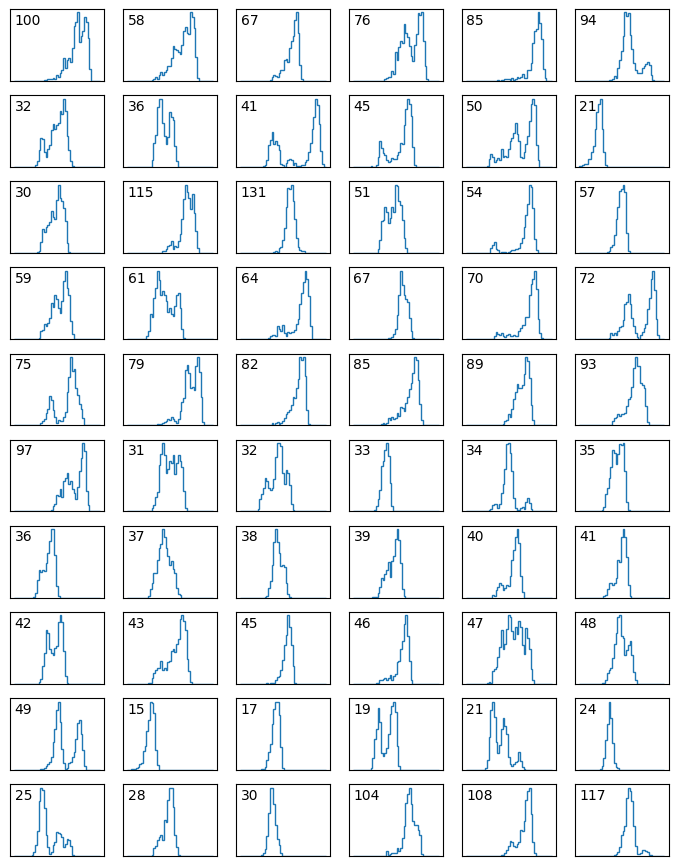

In [12]:
num_bins = 50
binedges_log_fpt = np.linspace(min_log_fpt, max_log_fpt, num_bins)

width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

row_stride = int(len(df_subset)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df_subset.itertuples():
    if row.Index % row_stride == 0:
        data = row.fpts
        where_data_zero = np.where(data == 0)[0]        
        where_data_nonzero = np.where(data != 0)[0]
        log_data = np.log10(data[where_data_nonzero])
        
        hist_log_fpt, _ = np.histogram(log_data, binedges_log_fpt, density=True)
        
        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.stairs(hist_log_fpt, binedges_log_fpt)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('hist_log_fpt.pdf', bbox_inches='tight', pad_inches=0)
plt.savefig('hist_log_fpt.pdf', bbox_inches='tight', pad_inches=0.25)

In [7]:
arr_seqlength = [] # sequence length
arr_medlogfpt = [] # median log fpt (first passage time)

for row in df_subset.itertuples():
    data = row.fpts
    where_data_zero = np.where(data == 0)[0]        
    where_data_nonzero = np.where(data != 0)[0]
    log_data = np.log10(data[where_data_nonzero])

    arr_seqlength.append(row.length)
    arr_medlogfpt.append(np.median(log_data))

arr_seqlength = np.array(arr_seqlength)
arr_medlogfpt = np.array(arr_medlogfpt)

np.savetxt('arr_seqlength.txt', arr_seqlength)
np.savetxt('arr_medlogfpt.txt', arr_medlogfpt)

In [9]:
min(arr_medlogfpt)

np.float64(-0.6716203965612623)

Text(0, 0.5, 'Median log FPT (first passage time)')

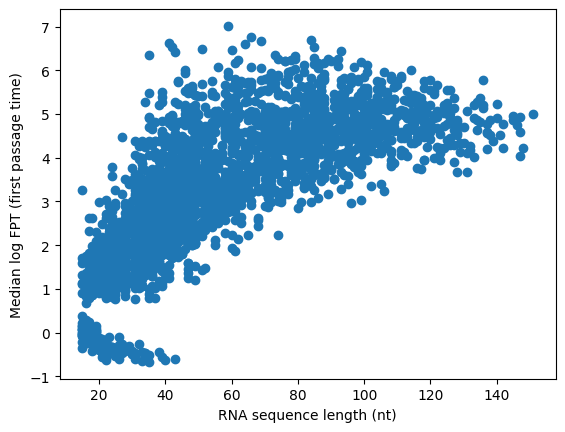

In [16]:
fig, ax = plt.subplots()

ax.scatter(arr_seqlength, arr_medlogfpt)
ax.set_xlabel('RNA sequence length (nt)')
ax.set_ylabel('Median log FPT (first passage time)')

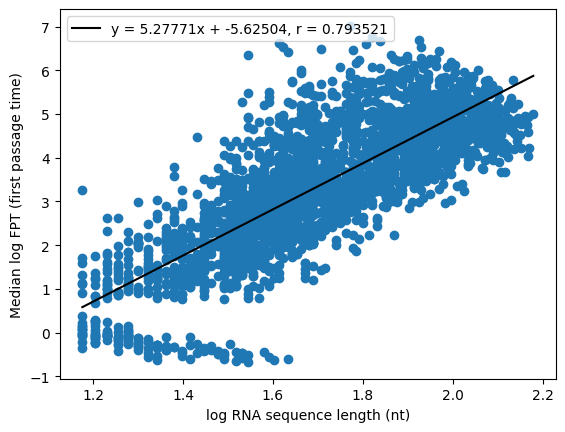

In [20]:
fig, ax = plt.subplots()

arr_logseqlength = np.log10(arr_seqlength)
ax.scatter(arr_logseqlength, arr_medlogfpt)
ax.set_xlabel('log RNA sequence length (nt)')
ax.set_ylabel('Median log FPT (first passage time)')

slope, intercept = np.polyfit(arr_logseqlength, arr_medlogfpt, 1)

y = arr_medlogfpt
y_hat = slope*arr_logseqlength + intercept
y_bar = np.mean(y)
sse = np.sum((y - y_hat)**2) # sum of squared errors
sst = np.sum((y - y_bar)**2) # sum of squares total
r2 = 1 - (sse / sst)
r = np.sqrt(r2)

ax.plot(np.array([min(arr_logseqlength), max(arr_logseqlength)]),
        slope*np.array([min(arr_logseqlength), max(arr_logseqlength)]) + intercept,
        color='black', label=f'y = {slope:.6g}x + {intercept:.6g}, r = {r:.6g}')
ax.legend()